In [23]:
%cd /content/drive/MyDrive/Colab Notebooks

/content/drive/MyDrive/Colab Notebooks


In [24]:
# ── 1. IMPORTS & STYLE ───────────────────────────────────────────────────────
import os, copy, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_curve, auc, accuracy_score
)
from sklearn.preprocessing import label_binarize

PALETTE  = ["#E74C3C", "#2980B9", "#27AE60"]
BG_COLOR = "#FFFFFF"; PLOT_BG = "#FAFAFC"; GRID_CLR = "#E0E4E8"
TEXT_CLR = "#2C3E50"; ACCENT  = "#F39C12"

plt.rcParams.update({
    "figure.facecolor": BG_COLOR, "axes.facecolor": PLOT_BG,
    "axes.edgecolor": "#BDC3C7", "axes.labelcolor": TEXT_CLR,
    "axes.titlecolor": TEXT_CLR, "axes.titleweight": "bold",
    "axes.titlesize": 14, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": TEXT_CLR, "ytick.color": TEXT_CLR, "text.color": TEXT_CLR,
    "grid.color": GRID_CLR, "grid.linestyle": "--", "grid.alpha": 0.8,
    "legend.facecolor": BG_COLOR, "legend.edgecolor": "#BDC3C7",
    "font.family": "sans-serif", "font.size": 11,
})


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# ── 2. CONFIG ─────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DATA_DIR   = "data/rice_disease"
OUTPUT_DIR = "outputs_dinov2_small_kfold"
CKPT_DIR   = "checkpoints_dinov2_small_kfold"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

IMG_SIZE       = 224
BATCH_SIZE     = 16
EPOCHS         = 30
LR             = 1e-4
LR_HEAD        = 1e-3
WEIGHT_DECAY   = 1e-4
NUM_WORKERS    = 2
UNFREEZE_EPOCH = 5
N_FOLDS        = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")


Device : cuda
GPU    : Tesla T4


Classes (3) : ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
Total images    : 120


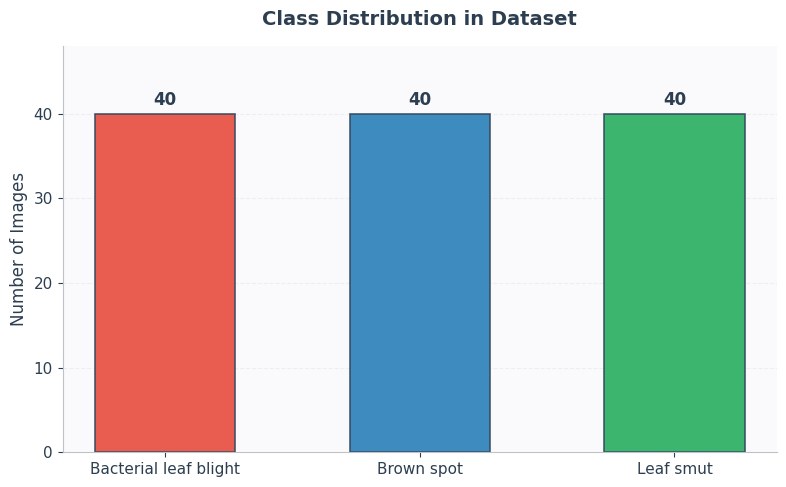

In [27]:
# ── 3. TRANSFORMS & DATASET ──────────────────────────────────────────────────
MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 64, IMG_SIZE + 64)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_dataset = datasets.ImageFolder(root=DATA_DIR)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)
all_labels   = [label for _, label in full_dataset.samples]
all_indices  = list(range(len(full_dataset)))
print(f"Classes ({NUM_CLASSES}) : {CLASS_NAMES}")
print(f"Total images    : {len(full_dataset)}")

class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset; self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

# Class distribution plot
def plot_class_distribution():
    counts = [all_labels.count(i) for i in range(NUM_CLASSES)]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(CLASS_NAMES, counts, color=PALETTE, width=0.55, edgecolor="#34495E", linewidth=1.2, alpha=0.9)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(count),
                ha="center", va="bottom", fontsize=12, fontweight="bold", color=TEXT_CLR)
    ax.set_title("Class Distribution in Dataset", pad=15)
    ax.set_ylabel("Number of Images", fontsize=12)
    ax.set_ylim(0, max(counts)*1.2); ax.grid(axis="y", alpha=0.5); ax.set_axisbelow(True)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR,"01_class_distribution.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_class_distribution()


In [28]:
# ── 4. MODEL ──────────────────────────────────────────────────────────────────
import timm

def build_dinov2_small(num_classes):
    # ADD dynamic_img_size=True to allow 224x224 inputs without crashing!
    model = timm.create_model('vit_small_patch14_dinov2', pretrained=True, num_classes=num_classes, dynamic_img_size=True)

    # Freeze backbone initially
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze the head
    for param in model.head.parameters():
        param.requires_grad = True

    return model


def get_optimizer(model, head_lr=LR_HEAD, backbone_lr=LR):
    head_params     = [p for p in model.head.parameters() if p.requires_grad]
    backbone_params = [p for p in model.parameters() if p.requires_grad and not any(p is hp for hp in head_params)]

    return optim.Adam([
        {"params": backbone_params, "lr": backbone_lr},
        {"params": head_params,     "lr": head_lr},
    ], weight_decay=WEIGHT_DECAY)



In [29]:
# ── 5. TRAINING FUNCTIONS ────────────────────────────────────────────────────
criterion_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    loop = tqdm(loader, leave=False, desc="Training")
    for images, labels in loop:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        loop.set_postfix(loss=loss.item())
    return running_loss / total, 100.0 * correct / total

def evaluate(model, loader):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    loop = tqdm(loader, leave=False, desc="Validating")
    with torch.no_grad():
        for images, labels in loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion_fn(outputs, labels)
            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return (running_loss/total, 100.0*correct/total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))


In [30]:
# ── 6. 5-FOLD TRAINING LOOP ──────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_histories = []
oof_preds, oof_labels, oof_probs = [], [], []

print("\n── DINOv2 Small | 5-Fold Cross Validation ──────────────────────")

for fold, (train_idx, val_idx) in enumerate(skf.split(all_indices, all_labels), start=1):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold}/{N_FOLDS} | Train: {len(train_idx)} | Val: {len(val_idx)}")
    print(f"{'='*60}")

    train_ds_fold = TransformSubset(Subset(full_dataset, train_idx), train_transforms)
    val_ds_fold   = TransformSubset(Subset(full_dataset, val_idx),   val_transforms)
    train_loader  = DataLoader(train_ds_fold, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
    val_loader    = DataLoader(val_ds_fold,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    model      = build_dinov2_small(NUM_CLASSES).to(DEVICE)
    optimizer  = get_optimizer(model)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    history    = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[],"lr":[]}
    best_val_acc   = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    CHECKPOINT     = os.path.join(CKPT_DIR, f"best_dinov2_small_fold{fold}.pth")

    for epoch in range(1, EPOCHS + 1):
        if epoch == UNFREEZE_EPOCH + 1:
            print(f"\n[Epoch {epoch}] Unfreezing the last 2 blocks for fine-tuning ...")
            for param in model.parameters():
                param.requires_grad = False
            for param in model.blocks[-2:].parameters():
                param.requires_grad = True
            for param in model.norm.parameters():
                param.requires_grad = True
            for param in model.head.parameters():
                param.requires_grad = True
            optimizer = get_optimizer(model, head_lr=LR_HEAD, backbone_lr=LR)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=EPOCHS - UNFREEZE_EPOCH, eta_min=1e-7)

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader)
        scheduler.step()

        current_lr = optimizer.param_groups[-1]["lr"]
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc);   history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        tag = ""
        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, CHECKPOINT)
            tag = "  ← Best Saved"

        print(f"Epoch [{epoch:02d}/{EPOCHS}] | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
              f"LR: {current_lr:.2e}{tag}")

    print(f"\nFold {fold} Best Val Accuracy : {best_val_acc:.2f}%")

    # ── Per-fold classification report (like our modular approach) ────────────
    model.load_state_dict(best_model_wts)
    _, _, fold_preds, fold_labels, fold_probs = evaluate(model, val_loader)

    fold_acc  = 100.0 * accuracy_score(fold_labels, fold_preds)
    fold_prec = precision_score(fold_labels, fold_preds, average='macro', zero_division=0)
    fold_rec  = recall_score(fold_labels, fold_preds, average='macro', zero_division=0)
    fold_f1   = f1_score(fold_labels, fold_preds, average='macro', zero_division=0)

    print(f"\n── Fold {fold} Metrics ──────────────────────────")
    print(f"  Accuracy : {fold_acc:.2f}%")
    print(f"  Precision: {fold_prec:.4f}")
    print(f"  Recall   : {fold_rec:.4f}")
    print(f"  F1 Score : {fold_f1:.4f}")
    print("\nPer-Class Report:")
    print(classification_report(fold_labels, fold_preds, target_names=CLASS_NAMES, zero_division=0))

    fold_histories.append(history)
    oof_preds.extend(fold_preds)
    oof_labels.extend(fold_labels)
    oof_probs.extend(fold_probs)



── DINOv2 Small | 5-Fold Cross Validation ──────────────────────

  FOLD 1/5 | Train: 96 | Val: 24


Training:   0%|          | 0/6 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch [01/30] | Train Loss: 1.2003 Acc: 35.42% | Val Loss: 1.0941 Acc: 37.50% | LR: 9.97e-04  ← Best Saved


Training:   0%|          | 0/6 [00:00<?, ?it/s]

...

Training:   0%|          | 0/6 [00:00<?, ?it/s]

Validating:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch [30/30] | Train Loss: 0.3371 Acc: 98.96% | Val Loss: 0.3344 Acc: 100.00% | LR: 1.00e-07

Fold 5 Best Val Accuracy : 100.00%


Validating:   0%|          | 0/2 [00:00<?, ?it/s]


── Fold 5 Metrics ──────────────────────────
  Accuracy : 100.00%
  Precision: 1.0000
  Recall   : 1.0000
  F1 Score : 1.0000

Per-Class Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      1.00      1.00         8
           Brown spot       1.00      1.00      1.00         8
            Leaf smut       1.00      1.00      1.00         8

             accuracy                           1.00        24
            macro avg       1.00      1.00      1.00        24
         weighted avg       1.00      1.00      1.00        24




  CROSS-VALIDATION AGGREGATED RESULTS (OUT-OF-FOLD)
  Overall Accuracy  : 95.00%
  Overall Precision : 0.9529
  Overall Recall    : 0.9500
  Overall F1 Score  : 0.9499

Per-class OOF Report:
                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      1.00      1.00        40
           Brown spot       0.89      0.97      0.93        40
            Leaf smut       0.97      0.88      0.92        40

             accuracy                           0.95       120
            macro avg       0.95      0.95      0.95       120
         weighted avg       0.95      0.95      0.95       120



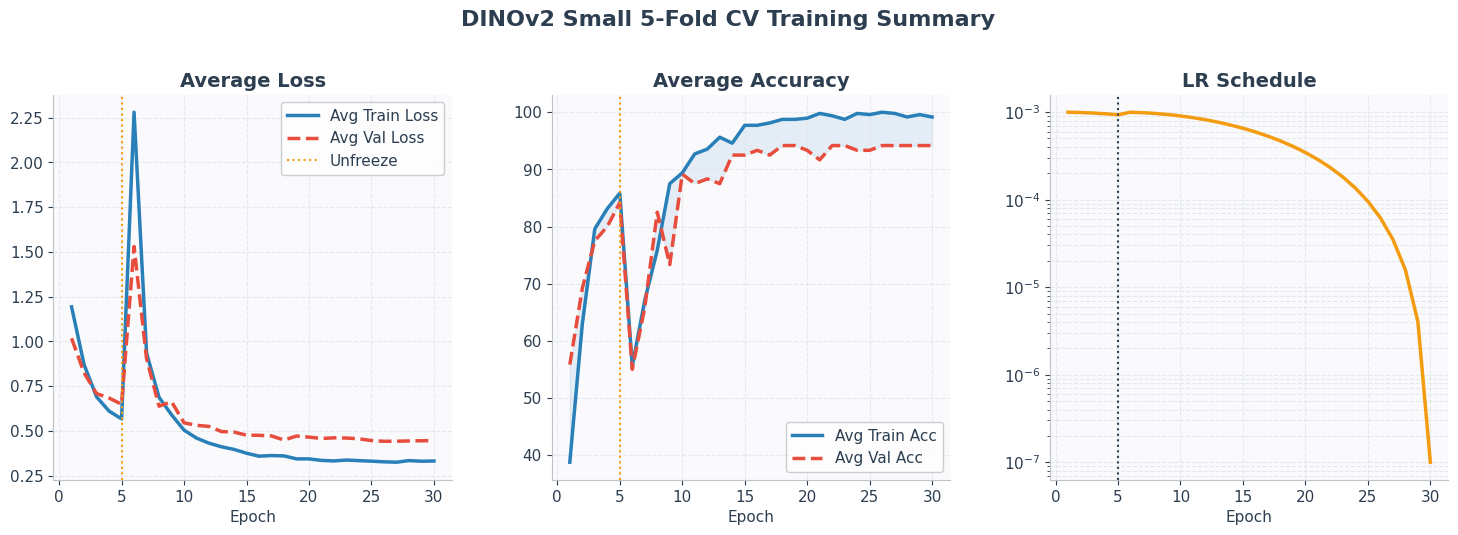

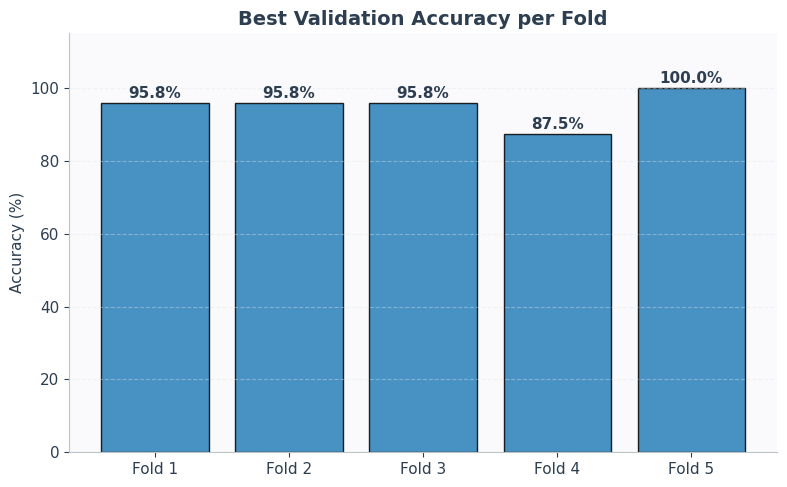

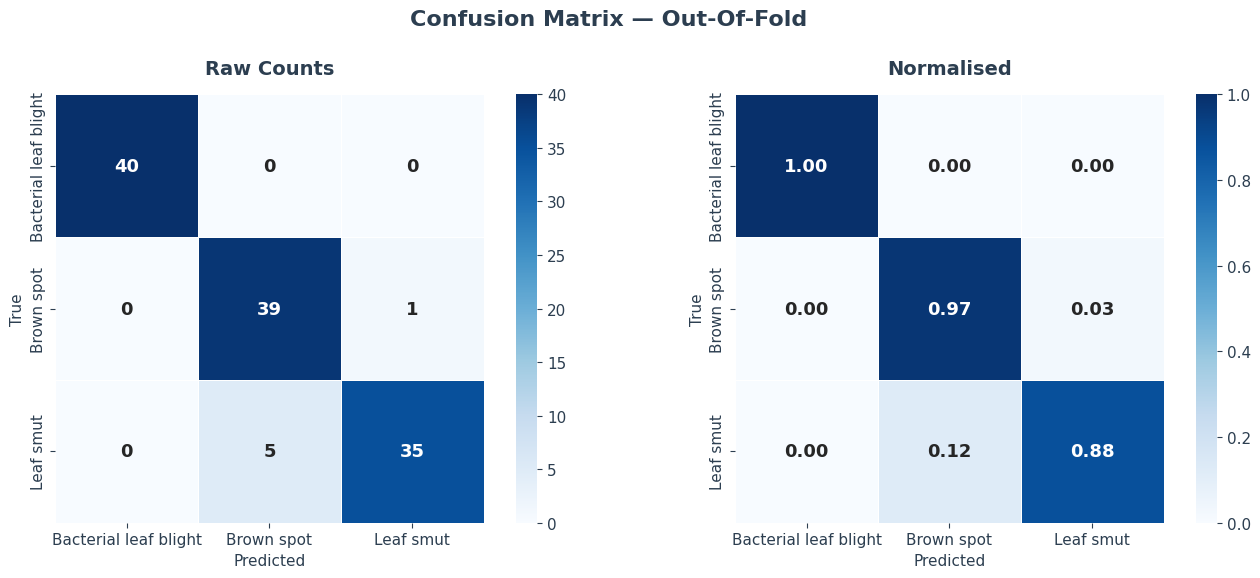

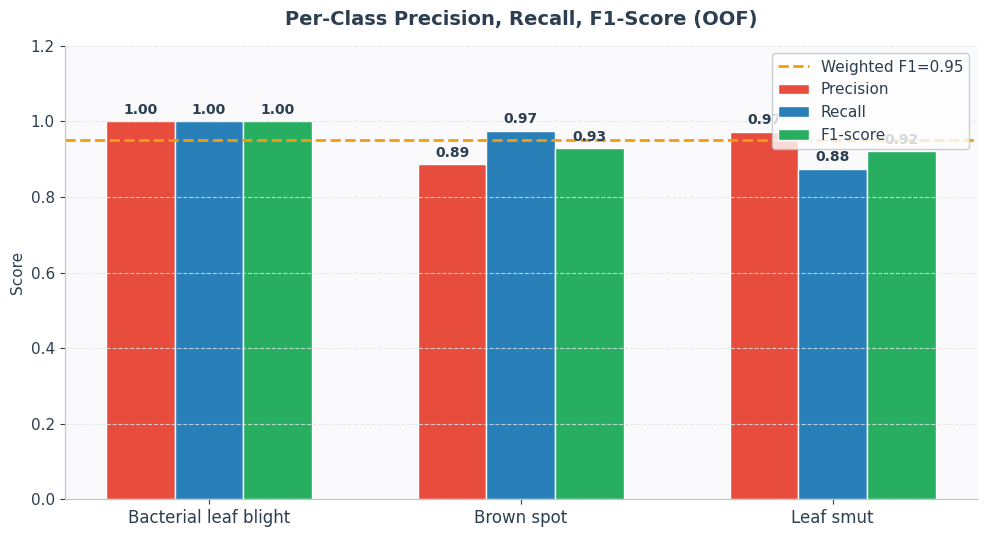

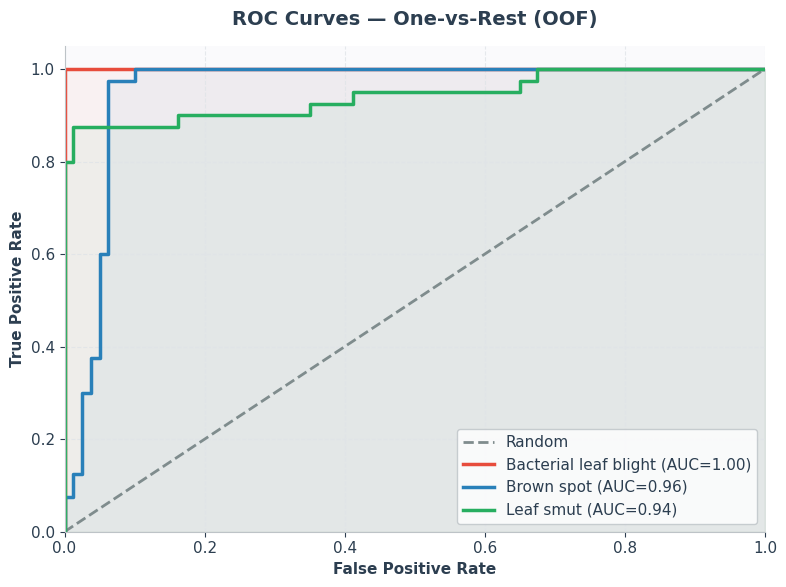

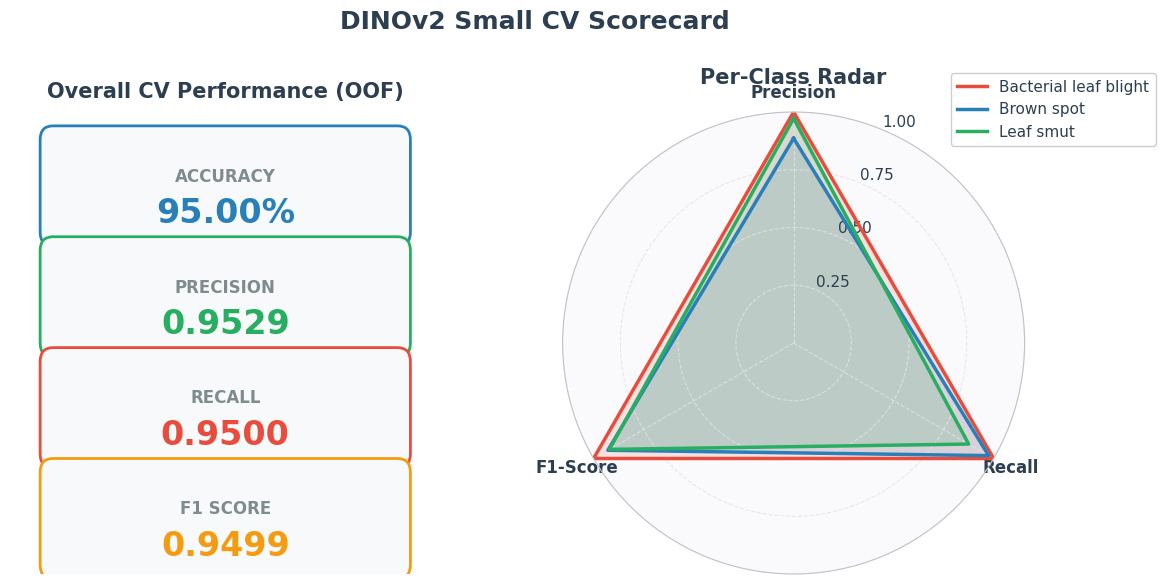


  All outputs saved to: outputs_dinov2_small_kfold


In [31]:
# ── 7. AGGREGATED OOF EVALUATION ─────────────────────────────────────────────
oof_preds  = np.array(oof_preds)
oof_labels = np.array(oof_labels)
oof_probs  = np.array(oof_probs)

acc       = 100.0 * (oof_preds == oof_labels).mean()
precision = precision_score(oof_labels, oof_preds, average="weighted", zero_division=0)
recall    = recall_score(   oof_labels, oof_preds, average="weighted", zero_division=0)
f1        = f1_score(       oof_labels, oof_preds, average="weighted", zero_division=0)

print("\n" + "="*60)
print("  CROSS-VALIDATION AGGREGATED RESULTS (OUT-OF-FOLD)")
print("="*60)
print(f"  Overall Accuracy  : {acc:.2f}%")
print(f"  Overall Precision : {precision:.4f}")
print(f"  Overall Recall    : {recall:.4f}")
print(f"  Overall F1 Score  : {f1:.4f}")
print("\nPer-class OOF Report:")
print(classification_report(oof_labels, oof_preds, target_names=CLASS_NAMES, zero_division=0))

# Average training curves
def plot_avg_curves(histories):
    epochs_range = range(1, EPOCHS + 1)
    avg_tl = np.mean([h["train_loss"] for h in histories], axis=0)
    avg_vl = np.mean([h["val_loss"]   for h in histories], axis=0)
    avg_ta = np.mean([h["train_acc"]  for h in histories], axis=0)
    avg_va = np.mean([h["val_acc"]    for h in histories], axis=0)
    lr_h   = histories[0]["lr"]

    fig = plt.figure(figsize=(18, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.25)

    ax0 = fig.add_subplot(gs[0])
    ax0.plot(epochs_range, avg_tl, color=PALETTE[1], lw=2.5, label="Avg Train Loss")
    ax0.plot(epochs_range, avg_vl, color=PALETTE[0], lw=2.5, linestyle="--", label="Avg Val Loss")
    ax0.axvline(UNFREEZE_EPOCH, color=ACCENT, lw=1.5, linestyle=":", label="Unfreeze")
    ax0.set_title("Average Loss"); ax0.set_xlabel("Epoch"); ax0.legend(); ax0.grid(True)

    ax1 = fig.add_subplot(gs[1])
    ax1.plot(epochs_range, avg_ta, color=PALETTE[1], lw=2.5, label="Avg Train Acc")
    ax1.plot(epochs_range, avg_va, color=PALETTE[0], lw=2.5, linestyle="--", label="Avg Val Acc")
    ax1.axvline(UNFREEZE_EPOCH, color=ACCENT, lw=1.5, linestyle=":")
    ax1.fill_between(epochs_range, avg_ta, avg_va, alpha=0.1, color=PALETTE[1])
    ax1.set_title("Average Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True)

    ax2 = fig.add_subplot(gs[2])
    ax2.plot(epochs_range, lr_h, color=ACCENT, lw=2.5)
    ax2.axvline(UNFREEZE_EPOCH, color=TEXT_CLR, lw=1.5, linestyle=":")
    ax2.set_title("LR Schedule"); ax2.set_xlabel("Epoch"); ax2.set_yscale("log"); ax2.grid(True, which="both")

    fig.suptitle("DINOv2 Small 5-Fold CV Training Summary", fontsize=16, fontweight="bold", y=1.05)
    fig.savefig(os.path.join(OUTPUT_DIR,"02_avg_training_curves.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_avg_curves(fold_histories)

# Fold bar chart
def plot_fold_bar():
    fold_accs = [max(h["val_acc"]) for h in fold_histories]
    folds = [f"Fold {i+1}" for i in range(N_FOLDS)]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(folds, fold_accs, color=PALETTE[1], edgecolor="black", alpha=0.85)
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, yval+0.5, f"{yval:.1f}%",
                ha="center", va="bottom", fontweight="bold")
    ax.set_title("Best Validation Accuracy per Fold"); ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 115); ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR,"03_fold_accuracy_bar.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_fold_bar()

# Confusion matrix
def plot_confusion_matrix(labels, preds, class_names):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    fig.suptitle("Confusion Matrix — Out-Of-Fold", fontsize=16, fontweight="bold", y=1.02)
    for ax, data, title, fmt in zip(axes, [cm, cm_norm], ["Raw Counts","Normalised"], ["d",".2f"]):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names,
                    ax=ax, linewidths=0.5, annot_kws={"size":13,"weight":"bold"}, square=True)
        ax.set_title(title, pad=15)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR,"04_confusion_matrix.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_confusion_matrix(oof_labels, oof_preds, CLASS_NAMES)

# Per-class metrics bar
def plot_per_class_metrics(labels, preds, class_names):
    report = classification_report(labels, preds, target_names=class_names, output_dict=True, zero_division=0)
    metrics   = ["precision","recall","f1-score"]
    x         = np.arange(len(class_names)); bar_width = 0.22
    fig, ax   = plt.subplots(figsize=(10, 5.5))
    for i, (metric, color) in enumerate(zip(metrics, PALETTE)):
        vals = [report[cls][metric] for cls in class_names]
        bars = ax.bar(x + i*bar_width, vals, bar_width, label=metric.capitalize(), color=color, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f"{val:.2f}",
                    ha="center", fontsize=10, fontweight="bold", color=TEXT_CLR)
    ax.set_xticks(x + bar_width); ax.set_xticklabels(class_names, fontsize=12)
    ax.set_ylim(0, 1.2); ax.set_ylabel("Score")
    ax.set_title("Per-Class Precision, Recall, F1-Score (OOF)", pad=15)
    overall_f1 = report["weighted avg"]["f1-score"]
    ax.axhline(overall_f1, color=ACCENT, lw=2, linestyle="--", label=f"Weighted F1={overall_f1:.2f}")
    ax.legend(loc="upper right"); ax.grid(axis="y")
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR,"05_per_class_metrics.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_per_class_metrics(oof_labels, oof_preds, CLASS_NAMES)

# ROC curves
def plot_roc_curves(labels, probs, class_names):
    y_bin = label_binarize(labels, classes=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0,1],[0,1], color="#7F8C8D", lw=2, linestyle="--", label="Random")
    for i, (cls, color) in enumerate(zip(class_names, PALETTE)):
        fpr, tpr, _ = roc_curve(y_bin[:,i], probs[:,i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2.5, label=f"{cls} (AUC={roc_auc:.2f})")
        ax.fill_between(fpr, tpr, alpha=0.05, color=color)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
    ax.set_xlabel("False Positive Rate", fontweight="bold")
    ax.set_ylabel("True Positive Rate",  fontweight="bold")
    ax.set_title("ROC Curves — One-vs-Rest (OOF)", pad=15)
    ax.legend(loc="lower right"); ax.grid(True)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR,"06_roc_curves.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_roc_curves(oof_labels, oof_probs, CLASS_NAMES)

# Scorecard
def plot_scorecard(acc, precision, recall, f1, class_names, labels, preds):
    fig = plt.figure(figsize=(14, 6))
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.1, width_ratios=[1,1.4])
    ax_left = fig.add_subplot(gs[0]); ax_left.axis("off")
    metrics_data = [("Accuracy",f"{acc:.2f}%",PALETTE[1]),("Precision",f"{precision:.4f}",PALETTE[2]),
                    ("Recall",f"{recall:.4f}",PALETTE[0]),("F1 Score",f"{f1:.4f}",ACCENT)]
    for idx, (name, value, color) in enumerate(metrics_data):
        y = 0.82 - idx*0.24
        ax_left.add_patch(mpatches.FancyBboxPatch((0.1,y-0.08),0.8,0.20,boxstyle="round,pad=0.03",
                          facecolor="#F8F9FA",edgecolor=color,linewidth=2,transform=ax_left.transAxes))
        ax_left.text(0.5,y+0.04,name.upper(),ha="center",va="center",fontsize=12,fontweight="bold",
                     color="#7F8C8D",transform=ax_left.transAxes)
        ax_left.text(0.5,y-0.04,value,ha="center",va="center",fontsize=24,fontweight="bold",
                     color=color,transform=ax_left.transAxes)
    ax_left.set_title("Overall CV Performance (OOF)", fontsize=15, pad=10)

    report = classification_report(labels, preds, target_names=class_names, output_dict=True, zero_division=0)
    cats   = ["Precision","Recall","F1-Score"]; N = len(cats)
    angles = [n/float(N)*2*np.pi for n in range(N)]; angles += angles[:1]
    ax_r   = fig.add_subplot(gs[1], polar=True)
    ax_r.set_facecolor(PLOT_BG); ax_r.set_theta_offset(np.pi/2); ax_r.set_theta_direction(-1)
    ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(cats, fontsize=12, fontweight="bold")
    ax_r.set_ylim(0,1); ax_r.set_yticks([0.25,0.5,0.75,1.0])
    for cls, color in zip(class_names, PALETTE):
        vals  = [report[cls]["precision"],report[cls]["recall"],report[cls]["f1-score"]]; vals += vals[:1]
        ax_r.plot(angles, vals, color=color, lw=2.5, label=cls)
        ax_r.fill(angles, vals, color=color, alpha=0.15)
    ax_r.legend(loc="upper right", bbox_to_anchor=(1.3,1.1))
    ax_r.set_title("Per-Class Radar", fontsize=15, pad=20)
    fig.suptitle("DINOv2 Small CV Scorecard", fontsize=18, fontweight="bold", y=1.05)
    fig.savefig(os.path.join(OUTPUT_DIR,"07_scorecard.png"), dpi=300, bbox_inches="tight")
    plt.show(); plt.close(fig)

plot_scorecard(acc, precision, recall, f1, CLASS_NAMES, oof_labels, oof_preds)

print("\n" + "="*60)
print("  All outputs saved to:", OUTPUT_DIR)
print("="*60)


In [39]:
import json

with open('DinoV2Small_KFold.ipynb', 'r') as f:
    nb = json.load(f)

# Remove problematic widget metadata
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

# THE FIX: Add indent=2 so GitHub can parse the base64 image plots!
with open('fixed_notebook.ipynb', 'w') as f:
    json.dump(nb, f, indent=2)

print("Fixed notebook saved as fixed_notebook.ipynb")


Fixed notebook saved as fixed_notebook.ipynb
